# **TP 1 : Transformée de Fourier, du discret au continu**
#            

On rappelle la définition de la fonction porte centrée en 0 et de largeur $1$ (porte unité): 
$$
\Pi\left(t\right) =
\begin{cases}
    1 & \text{si } |t| \leq \frac{1}{2}, \\
    0 & \text{sinon. }
\end{cases}
$$

Soit $a \in \mathbb{R}^*$. Nous travaillerons avec les fonctions $u_a(t)=e^{-a t^2}$. 

Pour pouvoir réaliser ce TP, il est essentiel d'avoir lu attentivement la préparation. Cette étape est cruciale pour comprendre les concepts et les méthodes qui seront abordés lors des travaux pratiques.


## **Rappel de la préparation**

Soit $u(t) \in L^1(\mathbb{R})$ un signal et $T>0$. Sa transformée de Fourier est définie par : 
$$ \hat{u}(f)=\int_{\mathbb{R}} u(t) e^{- 2 i \pi f t } dt$$

Le traitement numérique d'un signal impose un temps fini au signal : on ne connaît pas le signal $u$ sur $\mathbb{R}$ tout entier.

Pour modéliser une troncature temporelle du signal, on peut multiplier le signal $u$ par  une fonction porte centrée en 0 de largeur $T$ : 
$$u_{|T}(t)=u(t)\Pi\left(\frac{t}{T}\right).$$

On peut approximer $\hat{u}(f)$ par $\displaystyle \widehat{u_{|T}}(f)=\int_{-T/2}^{T/2} u(t) e^{- 2 i \pi f t } dt$ :

$$\lim_{T \to +\infty} \widehat{u_{|T}}(f) = \lim_{T \to +\infty} \int_{-T/2}^{T/2} u(t) e^{- 2 i \pi f t } dt =  \int_{\mathbb{R}} u(t) e^{- 2 i \pi f t }dt =\hat{u}(f)$$

Soit $N \in \mathbb{N}^*$. On découpe l'intervalle $\displaystyle \left[-\frac{T}{2},\frac{T}{2}\right]$ en N intervalles de longueur $\displaystyle \frac{T}{N}$  : $$t_k=-\frac{T}{2}+k\frac{T}{N}$$ pour $k=0, ..., N$.


On rappelle que  $$ S_{T,N,u}(f)=   \frac{T}{N}  e^{ i \pi f T } \sum_{k=0}^{N-1} u(t_k)e^{-2 i \pi f k T/N } \,\,\,\,\,\,\,\,\,\, (\star)$$ est une approxiation de $\hat{u}(f)$ (voir la préparation pour plus de détails).


Dans les parties I et II, nous proposons deux méthodes numériques pour calculer $(\star)$, l'une en programmant directement la somme à l'aide d'une bouce for et l'autre utilisant l'algorithme de fft pré-programmé. 

## **Partie I :   Calcul direct de $(\star)$** (sur 10 points)

#### 1) Coder en python une fonction qui dépend de $t$ et $a$ et qui renvoie la valeur de $u_a(t)=e^{-a t^2}$.

In [142]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.fft
import time

def u_a(t,a):
    return np.exp(-a*t**2)

#### 2) Que vaut $\widehat{u_a}(f)$ (voir TD) ? Coder en python une fonction qui dépend de $f$ et $a$ et qui renvoie $\widehat{u_a}(f)$.

In [124]:
def F_ua(f,a):
    return (np.sqrt(np.pi/a)*np.exp((-(np.pi*f)**2)/a))

#### 3) Représenter $u_{\pi}$ et sa transformée de Fourier sur le même graphique. On légendera le graphique et on ajoutera un titre. Commenter le résultat obtenu.

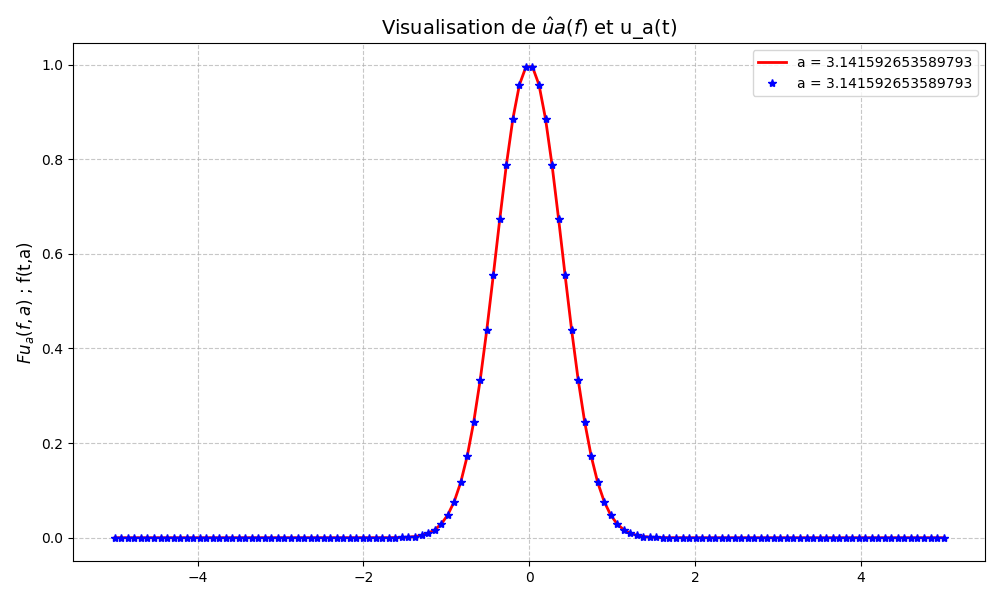

In [125]:
#Paramètres
a = np.pi
T=10
N=2**7
t = np.linspace(-T/2, T/2, N)
f = np.linspace(-T/2, T/2, N)

#tracé du graphique
plt.figure(figsize=(10, 6))
plt.plot(t, u_a(t,a),'r', label=f'a = {a}', linewidth=2)
plt.plot(f, F_ua(f,a),'b*', label=f'a = {a}', linewidth=2)

#Personnalisation du graphique
plt.title(r'Visualisation de $\hat{u}a(f)$ et u_a(t)', fontsize=14)
plt.ylabel(r'$F{u_a}(f, a)$ ; f(t,a)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

#Ajustement de l'espacement et affichage
plt.tight_layout()
plt.show()

#### **1 pt** : figure correcte (on distinque bien les 2) et seulement 0,5 si les deux courbes sont indiscernables visuellement
#### **0.5 pt** : légende présente et claire 

In [155]:
**Commentaire :**
On observe graphiquement que les deux courbes sont parfaitement superposées. Cela illustre la propriété remarquable de la fonction $u_\pi(t) = e^{-\pi t^2}$ qui est son propre point fixe pour l'opérateur de Fourier : $\widehat{u_\pi} = u_\pi$.

  File "<basthon-input-155-b32178c56bcc>", line 1
    **Commentaire :**
    ^^
SyntaxError: invalid syntax


On peut voir que 𝑢𝜋 est égale à sa transformée de Fourier.

#### 4) Représenter sur un même graphique $u_a$ pour  $a \in \{1/4, 1, 4, 10\}$. Même question pour $\widehat{u_a}$. Quelle propriété vue en cours ces graphiques illustrent-ils ? On légendera les graphiques et on ajoutera des titres.

#### **0.5 point** : figure légendé pour $u_a$
#### **0.5 point** : figure légendée $\widehat{u_a}$
#### **0.5 point** : légende en fonction de $a$
#### **1 point** : commentaire basé sur la formule du cours

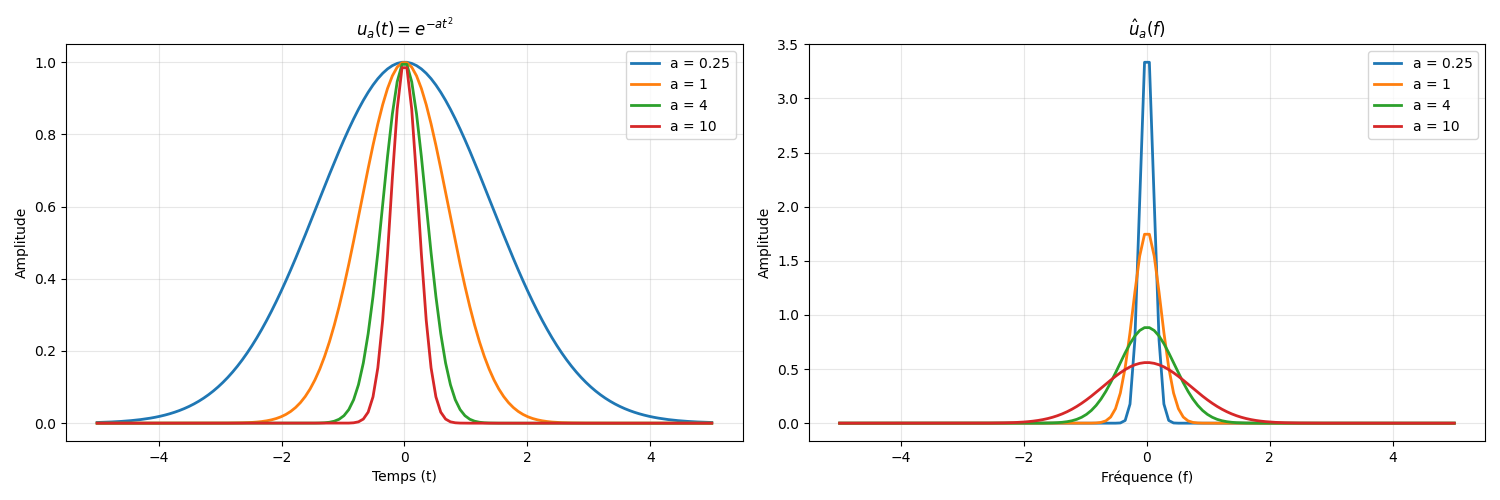

In [126]:
# Paramètres
i = [1/4, 1, 4, 10]
T = 10
N = 2**7
t = np.linspace(-T/2, T/2, N)
f = np.linspace(-T/2, T/2, N)

# Fonctions
def ua(t, a): return np.exp(-a * t**2)
def F_ua(f, a): return np.sqrt(np.pi/a) * np.exp(-(np.pi**2 * f**2)/a)

# Tracé du graphique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for a in i:
    # On définit la couleur une seule fois par itération pour les deux axes
    line, = ax1.plot(t, u_a(t, a), linewidth=2, label=f'a = {a}')
    color = line.get_color() # On récupère la couleur auto-générée
    
    ax2.plot(f, F_ua(f, a), color=color, linewidth=2, label=f'a = {a}')

# Configuration Axe 1
ax1.set_title(r'$u_a(t) = e^{-at^2}$')
ax1.set_xlabel('Temps (t)')
ax1.set_ylabel('Amplitude')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Configuration Axe 2
ax2.set_title(r'$\hat{u}_a(f)$')
ax2.set_xlabel('Fréquence (f)')
ax2.set_ylabel('Amplitude')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

**Commentaire :**
Ces graphiques illustrent le **principe d'incertitude temps-fréquence**.
Mathématiquement, la largeur d'une gaussienne $e^{-at^2}$ est inversement proportionnelle à $\sqrt{a}$. Sa TF est proportionnelle à $e^{-\frac{\pi^2 f^2}{a}}$, dont la largeur est proportionnelle à $\sqrt{a}$.
On observe bien que :
* Plus **$a$ est petit** (ex: $a=1/4$), plus le signal $u_a(t)$ est **étalé** dans le temps, et plus sa TF $\widehat{u_a}(f)$ est **piquée** (étroite et haute) en fréquence.
* Inversement, plus **$a$ est grand** (ex: $a=10$), plus le signal $u_a(t)$ est **piqué** dans le temps, et plus sa TF $\widehat{u_a}(f)$ est **étalée** (large et basse) en fréquence.
Une concentration dans un domaine entraîne inévitablement un étalement dans l'autre.

#### 5) Nous allons chercher à calculer numériquement la transformée de Fourier de $u_1$ en utilisant la formule $(\star)$ : 
 $$ S_{T,N,u_1}(f)=   \frac{T}{N}  e^{ i \pi f T } \sum_{k=0}^{N-1} u_1(t_k)e^{-2 i \pi f k T/N } \approx \hat{u}_1(f) \,\,\,\,\,\,\,\,\,\,$$


#### a) Ecrire une fonction, nommée $TFsignal$ qui prend en paramètre d'entrée $(f, u, T)$ et qui renvoit la valeur de 
 $$ S_{T,N,u_1}(f) = \frac{T}{N}  e^{ i \pi f T } \sum_{k=0}^{N-1} u[k]e^{-2 i \pi f k T/N }$$



#### **1 point** 

   - f est la fréquence en laquelle on va calculer la transformée de Fourier ;
   - u est le vecteur de taille N qui contient toutes les valeurs du signal dont on veut calculer la transformée de Fourier en temps : u=[u[0],u[1],...,u[N-1]] ;
   - T est le paramètre utiliser pour le fenêtrage.



In [127]:
def TFsignal(f, u, T):
    N = len(u)
    k = np.arange(N)
    
    if np.isscalar(f):
        somme = np.sum(u * np.exp(-2j * np.pi * f * k * T / N))
        resultat = (T / N) * np.exp(1j * np.pi * f * T) * somme
    else:
        f_vec = np.array(f)
        exponentielles = np.exp(-2j * np.pi * f_vec[:, np.newaxis] * k[np.newaxis, :] * T / N)
        somme = np.dot(exponentielles, u)
        resultat = (T / N) * np.exp(1j * np.pi * f_vec * T) * somme
        
    return resultat

#### b) Pourquoi la fonction *TFsignal* de dépend pas de N ?

La fonction TFsignal ne dépend pas de N car N dépend de u et N est défini à partir de u donc on peut le déduire à partir des paramètres f,u et T.

#### 6) a) Quelle est la périodicité de 
#### $$S_{T,N,u_1} \, : \,  f \mapsto \left |\frac{T}{N}  e^{ i \pi f T } \sum_{k=0}^{N-1} u_1(t_k)e^{-2 i \pi f k T/N }\right| $$ ? 
#### b) Représentez  $f \mapsto |S_{T,N,u_1}(f)|$ sur un intervalle bien choisi de façon à pouvoir visualiser la périodicité. On utilisera la fonction TFsignal précédemment programmée. 
#### c) Tracez sur le même graphique la transformée de Fourier de $u_1$ en utilisant la fonction programmée à la question 2). 

𝑆𝑇,𝑁,𝑢1 est N/T périodique.

#### **(b) 1 pt** : 1 pt pour graphe on visualise la période la période
#### **(c) 1 pt** : 0.5 pt pour figure correcte sur laquelle on visualise les 2 (approximée et exacte) et 0.5 pt pour légende lisible

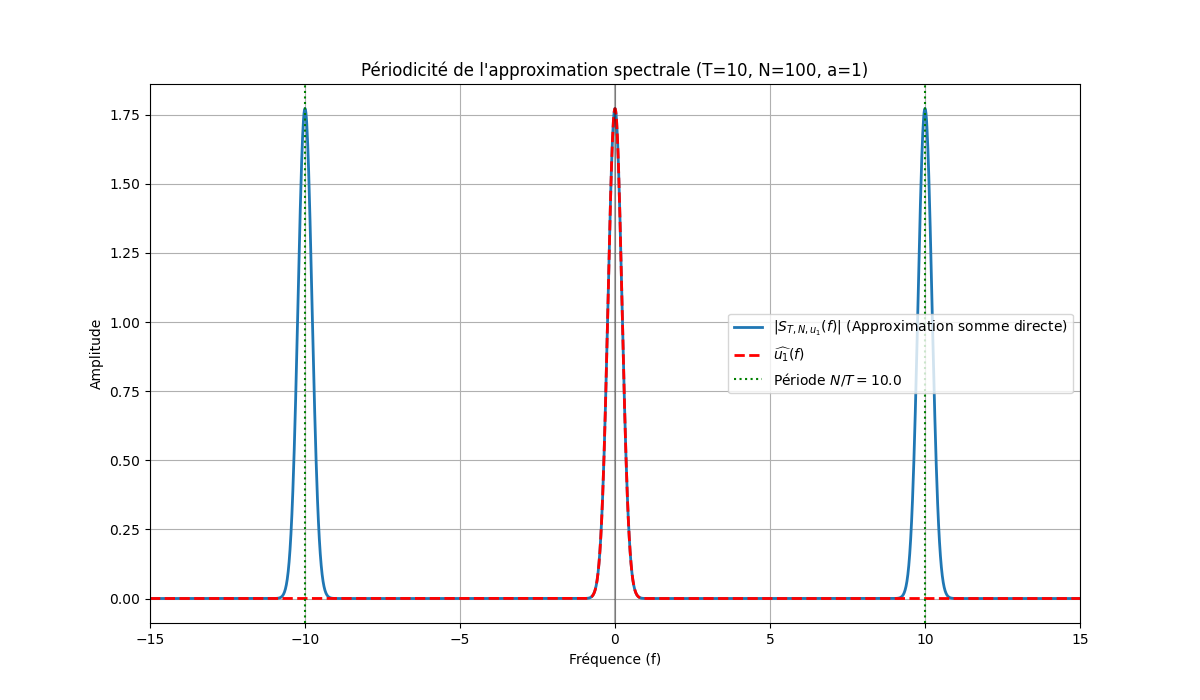

In [129]:
T_6 = 10
N_6 = 100
a_1 = 1

# Période théorique calculée en 6a
Fe_6 = N_6 / T_6 # = 10 Hz

# Grille de fréquences couvrant un peu plus de 2 périodes pour visualiser
f_6 = np.linspace(-1.5 * Fe_6, 1.5 * Fe_6, 2000)

# Échantillonnage temporel de u_1
k_6 = np.arange(N_6)
t_k_6 = -T_6/2 + k_6 * T_6 / N_6
u_1_ech = u_a(t_k_6, a_1)

# Calcul TF approchée (somme directe) et exacte
stn_u1 = TFsignal(f_6, u_1_ech, T_6)
tf_exacte_6 = F_ua(f_6, a_1)

plt.figure(figsize=(12, 7))
plt.plot(f_6, np.abs(stn_u1), label=r'$|S_{T,N,u_1}(f)|$ (Approximation somme directe)', linewidth=2)
plt.plot(f_6, tf_exacte_6, '--', label=r'$\widehat{u_1}(f)$', color='red', linewidth=2)

plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=Fe_6, color='green', linestyle=':', label=f'Période $N/T = {Fe_6}$')
plt.axvline(x=-Fe_6, color='green', linestyle=':')

plt.title(f'Périodicité de l\'approximation spectrale (T={T_6}, N={N_6}, a={a_1})')
plt.xlabel('Fréquence (f)')
plt.ylabel('Amplitude')
plt.xlim(-1.5 * Fe_6, 1.5 * Fe_6)
plt.legend()
plt.grid(True)
plt.show()

#### 7) **On prend $a=1$ dans cette question.**
#### a) Pour  $T \in \{0.5,1,2,3,6\}$, tracez sur un même graphique l'approximation de la transformée de Fourier de $u_1$ obtenue grâce à la fonction $TFsignal$ sur l'intervalle $[-5,5]$.
#### b) Même question pour $T \in \{6,8,10\}$.
#### c)  Tracez la norme $L^2(\R)$ de l'erreur (erreur entre l'approximation de la transformée de Fourier obtenue grâce à la fonction  $S_{T,N,u_1}$ et la transformée de Fourier exacte de $u_1$) en fonction de $T$. En déduire une valeur de $T$ convenable d'un point de vue numérique.

#### **(a) 0.5 pt** : pour graphe légendé
#### **(b) 0.5 pt** : pour graphe légendé
#### **(c) 2 pts** : 1 pt pour figure de l'erreur correcte et 1 pt pour commentaire


**Calcul de l'erreur $L^2$ :**
L'erreur est $\varepsilon_T(f) = S_{T,N,u_1}(f) - \hat{u}_1(f)$. On cherche à calculer sa norme $L^2$ :
$$\|\varepsilon_T\|_2 = \sqrt{ \int_{\mathbb{R}} |S_{T,N,u_1}(f) - \hat{u}_1(f)|^2 df }$$
Numériquement, on approxime cette intégrale sur l'intervalle d'étude $[-5, 5]$ en utilisant la méthode des trapèzes (`np.trapz`).

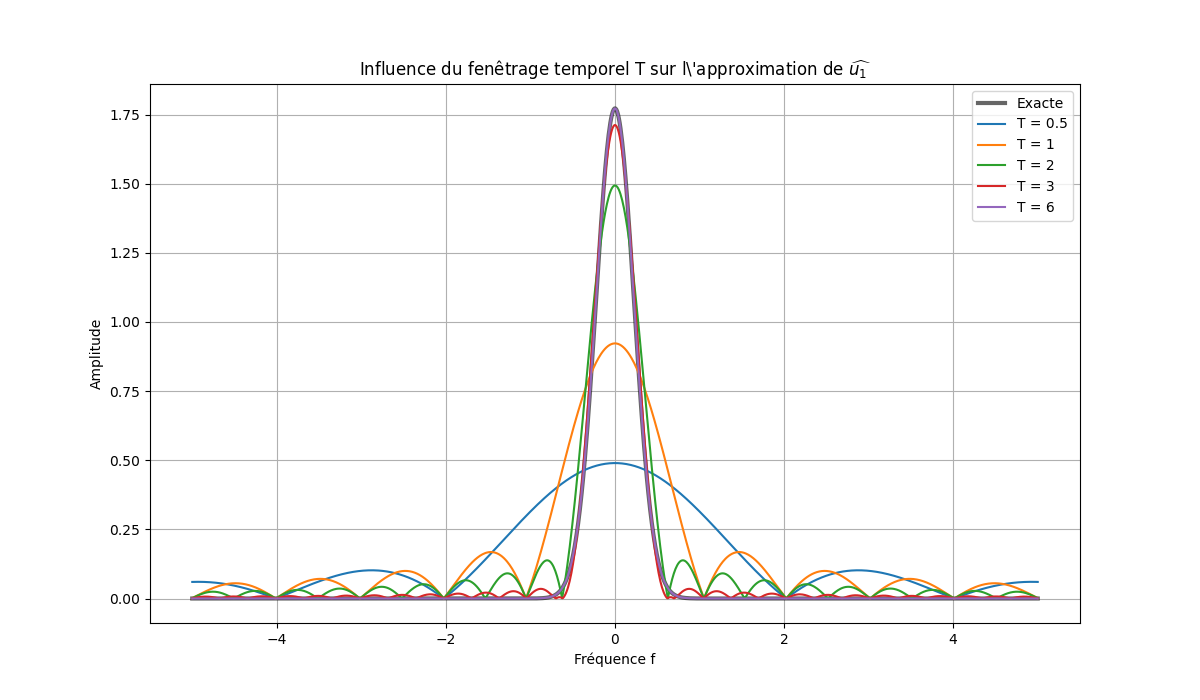

In [132]:
T_values_a = [0.5, 1, 2, 3, 6]
N_fixed = 512 # On prend ici N, puissance de 2
f_7a = np.linspace(-5, 5, 1000)
a_1 = 1

plt.figure(figsize=(12, 7))

# TF exacte pour pouvoir comparer
plt.plot(f_7a, F_ua(f_7a, a_1), 'k-', linewidth=3, label='Exacte', alpha=0.6)

for T in T_values_a:
    k = np.arange(N_fixed)
    t_k = -T/2 + k * T / N_fixed
    u_ech = u_a(t_k, a_1)
    stn = TFsignal(f_7a, u_ech, T)
    plt.plot(f_7a, np.abs(stn), label=f'T = {T}')

plt.title(r'Influence du fenêtrage temporel T sur l\'approximation de $\widehat{u_1}$')
plt.xlabel('Fréquence f')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

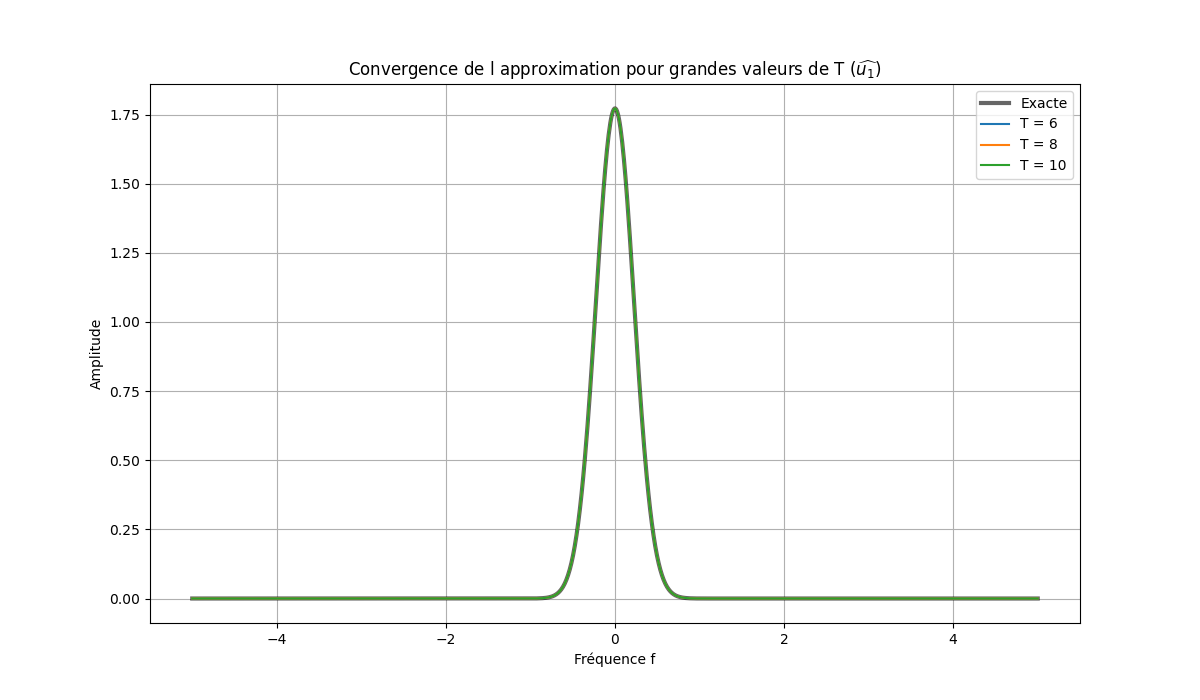

In [133]:
T_values_b = [6, 8, 10]
N_fixed = 512
f_7b = np.linspace(-5, 5, 1000)
a_1 = 1

plt.figure(figsize=(12, 7))

# TF exacte pour comparaison
plt.plot(f_7b, F_ua(f_7b, a_1), 'k-', linewidth=3, label='Exacte', alpha=0.6)

for T in T_values_b:
    k = np.arange(N_fixed)
    t_k = -T/2 + k * T / N_fixed
    u_ech = u_a(t_k, a_1)
    stn = TFsignal(f_7b, u_ech, T)
    plt.plot(f_7b, np.abs(stn), label=f'T = {T}')

plt.title(r'Convergence de l approximation pour grandes valeurs de T ($\widehat{u_1}$)')
plt.xlabel('Fréquence f')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

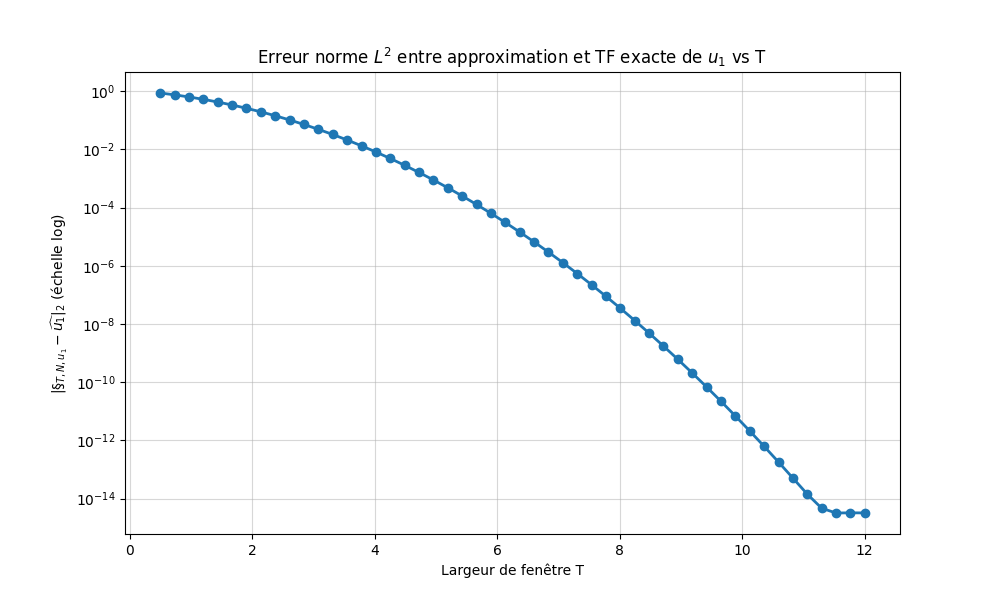

In [135]:
T_range = np.linspace(0.5, 12, 50)
N_error = 1024 # toujours N puissance de 2
f_error = np.linspace(-5, 5, 1000) # Intervalle d'intégration numérique
df = f_error[1] - f_error[0]
a_1 = 1

tf_exacte_err = F_ua(f_error, a_1)
errors_L2 = []

for T in T_range:
    k = np.arange(N_error)
    t_k = -T/2 + k * T / N_error
    u_ech = u_a(t_k, a_1)
    stn = TFsignal(f_error, u_ech, T)
    diff = stn - tf_exacte_err
    norm_L2_sq = np.trapz(np.abs(diff)**2, f_error)
    errors_L2.append(np.sqrt(norm_L2_sq))

plt.figure(figsize=(10, 6))
plt.plot(T_range, errors_L2, 'o-', linewidth=2)
plt.yscale('log') 
plt.title(r'Erreur norme $L^2$ entre approximation et TF exacte de $u_1$ vs T')
plt.xlabel('Largeur de fenêtre T')
plt.ylabel(r'$\|\S_{T,N,u_1} - \widehat{u_1}\|_2$ (échelle log)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [156]:
**Commentaire sur le choix de T :**
Le graphique montre que l'erreur décroît de manière exponentielle à mesure que $T$ augmente (l'erreur de troncature devient négligeable car le signal décroît très vite).
On observe une stabilisation de l'erreur (liée à la précision numérique et à la discrétisation) à partir de **$T \approx 8$**. Pour $u_1$, choisir **$T=10$** est donc tout à fait convenable d'un point de vue numérique pour garantir que l'ensemble du signal utile est capturé.

  File "<basthon-input-156-b145b02d7a9c>", line 2
    Le graphique montre que l'erreur décroît de manière exponentielle à mesure que $T$ augmente (l'erreur de troncature devient négligeable car le signal décroît très vite).
                                                                                                                                                                           ^
SyntaxError: unmatched ')'


## **Partie II : Utilisation de la TFD pour calculer $(\star)$** (sur 8 points)

Nous allons maintenant voir comment faire le lien entre transformée de Fourier continu et transformée de Fourier discrète, de manière a pouvoir utiliser l'algorithme de fft qui est un algorithme très robuste.

On rappelle que  :
$$ S_{T,N,u}(f)=   \frac{T}{N}  e^{ i \pi f T } \sum_{k=0}^{N-1} u(t_k)e^{-2 i \pi f k T/N } \,\,\,\,\,\,\,\,\,\, (\star)$$


Soit $x=(x[n])_{n=0,...,N-1}$ un signal fini de longueur N. On rappelle que la transformée de Fourier discrète (abréviation TFD en français et DFT en anglais) de x, notée X, est le signal discret définit comme suit (cf semestre 5):

$$ X[m]=\sum_{k=0}^{N-1} x[k] e^{-2i\pi m k/N} $$
pour $m=0,..., N-1$.

#### 8) Soit $0 \leq m \leq N-1$. On note $U[m]$ la TFD du signal discret défini par $u[n]=u(t_n)$ pour $n=0,...,N-1$.
#### En évaluant $S_{T,N,u}$ en la fréquence $\displaystyle f_m=\frac{m}{T}$, montrer que 
#### $$ S_{T,N,u}(f_m)=   \frac{T}{N}  e^{ i \pi m } U[m]$$

$$ S_{T,N,u}(fm)=   \frac{T}{N}  e^{ i \pi m  } \sum{k=0}^{N-1} u(t_k)e^{-2 i \pi  k m/N } = \frac{T}{N}  e^{ i \pi m  } U[m] $$

#### 9) Nous allons utiliser la formule
$$ S_{T,N,u}(f_m)=   \frac{T}{N}  e^{ i \pi m } U[m], $$
#### avec $U[m]$ la TFD du signal discret défini par $u[n]=u(t_n)$ pour $n=0,...,N-1$, pour calculer la transformée de Fourier du signal $u$ en utilisant l'algorithme de fft.

#### Le module `scipy.fft` disponible avec la bibliothèque Scipy contient différents fonctions utiles pour le calcul de la DFT. 

#### Utiliser l'aide pour obtenir un descriptif de ses possibilités, en particulier concernant `scipy.fft.fft` et `scipy.fft.fftfreq`. 

#### Quel algorithme est  utilisé pour calculer la DFT d'un signal discret ? Préciser à quelles fréquences correspond la DFT renvoyée.  

In [ ]:
L'algorithme utilisé est l'algorithme de Bluestein

In [137]:
import scipy.fft 

help(scipy.fft.fft)

Help on _Function in module scipy.fft._basic:

fft(x, n=None, axis=-1, norm=None, overwrite_x=False, workers=None, *, plan=None)
    Compute the 1-D discrete Fourier Transform.

    This function computes the 1-D *n*-point discrete Fourier
    Transform (DFT) with the efficient Fast Fourier Transform (FFT)
    algorithm [1]_.

    Parameters
    ----------
    x : array_like
        Input array, can be complex.
    n : int, optional
        Length of the transformed axis of the output.
        If `n` is smaller than the length of the input, the input is cropped.
        If it is larger, the input is padded with zeros. If `n` is not given,
        the length of the input along the axis specified by `axis` is used.
    axis : int, optional
        Axis over which to compute the FFT. If not given, the last axis is
        used.
    norm : {"backward", "ortho", "forward"}, optional
        Normalization mode. Default is "backward", meaning no normalization on
        the forward transforms

In [138]:
help(scipy.fft.fftfreq)

Help on function fftfreq in module scipy.fft._helper:

fftfreq(n, d=1.0, *, xp=None, device=None)
    Return the Discrete Fourier Transform sample frequencies.

    The returned float array `f` contains the frequency bin centers in cycles
    per unit of the sample spacing (with zero at the start).  For instance, if
    the sample spacing is in seconds, then the frequency unit is cycles/second.

    Given a window length `n` and a sample spacing `d`::

      f = [0, 1, ...,   n/2-1,     -n/2, ..., -1] / (d*n)   if n is even
      f = [0, 1, ..., (n-1)/2, -(n-1)/2, ..., -1] / (d*n)   if n is odd

    Parameters
    ----------
    n : int
        Window length.
    d : scalar, optional
        Sample spacing (inverse of the sampling rate). Defaults to 1.
    xp : array_namespace, optional
        The namespace for the return array. Default is None, where NumPy is used.
    device : device, optional
        The device for the return array.
        Only valid when `xp.fft.fftfreq` implemen

C'est l'algorithme fft (fast fourier transform) qui est utilisé pour calculé la DFT. 
On utilise `scipy.fft.fft` pour calculer la DFT d'un signal. Lorsque l'on veut calculer la DFT d'un signal discret x de longueur N, l'utilisation de la commande `scipy.fft.fft` nous renvoie un un signal discret de même taille que $x$. 
Pour pouvoir interpréter le résultat obtenu (ou tracer la DFT obtenue par exemple), il est important de comprendre  quelles sont les fréquences correspondantes. 

On peut utiliser la commande `scipy.fft.fftfreq` pour récupérer les fréquences. Il faut rentrer deux paramètres : la longeur du signal et la fréquence d'échantillonnage, ce qui correspondant dans notre cas à $\frac{T}{N}$.



Il faut également prêter attention au fait que les fréquences négatives sont comprises dans l'intervalles $[T/2,T]$ : 


Si on reprend les notations données par l'aide, on a (je cite) :


Given a window length `n` and a sample spacing `d`:
    
      f = [0, 1, ...,   n/2-1,     -n/2, ..., -1] / (d*n)   if n is even
      f = [0, 1, ..., (n-1)/2, -(n-1)/2, ..., -1] / (d*n)   if n is odd
      
      
Ici $d=\frac{T}{N}$ et $n=N$ la longueur du signal.

#### 10) On rappelle que $u_a(t)=e^{-at^2}$. 
#### Caculer la DFT de $u_1$ à l'aide de la fonction `scipy.fft.fft` disponible dans la bibliothèque SciPy puis utiliser ce résultat  pour tracer l'approximation de la transformée de Fourier de $u_1$ donnée par
$$S_{T,N,u_1}(f_m)=   \frac{T}{N}  e^{ i \pi m } U_1[m], $$
#### avec $U_1[m]$ la TFD du signal discret défini par $u[n]=u_1(t_n)$ pour $n=0,...,N-1$.
#### Tracer sur le même graphique la transformée de Fourier exacte de $u_1(t)$ (fonction programmée à la question 2)). Commenter le résultat obtenu.

#### **1 pt** : pour DFT
#### **1 pt** : figure correcte (on distinque bien les 2) et seulement 0,5 si les deux courbes sont indiscernables visuellement
#### **0,5 pt** : légende présente et claire

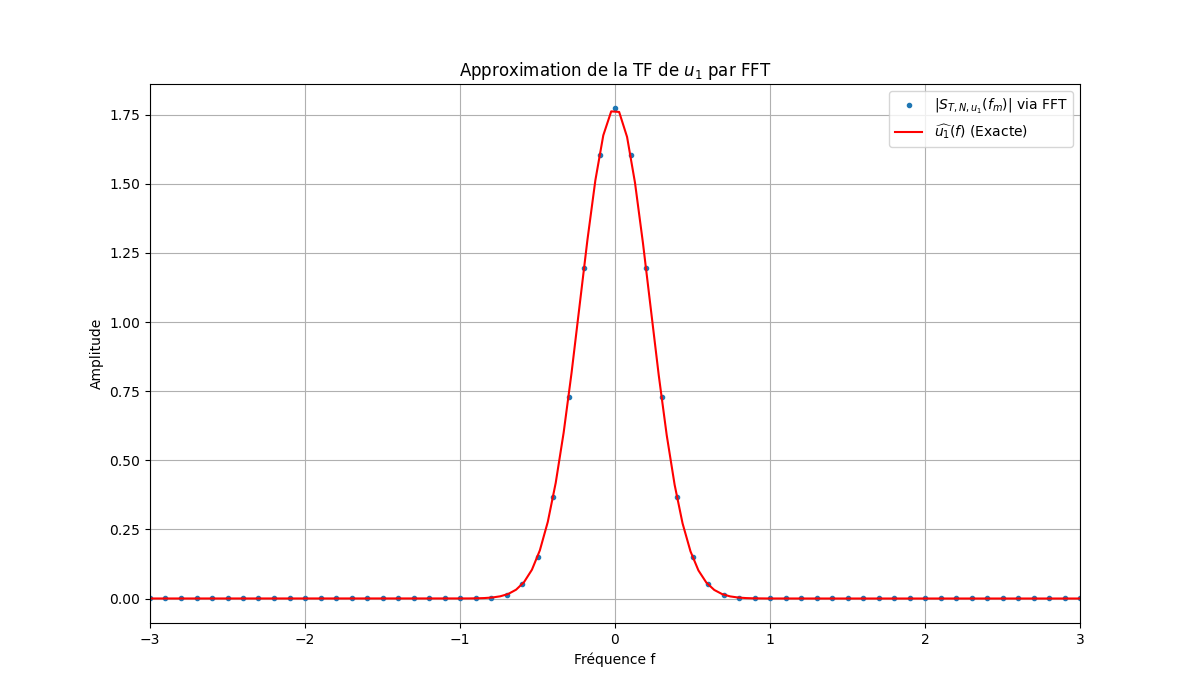

In [140]:
T_10, N_10, a_1 = 10, 512, 1
k_10 = np.arange(N_10)
t_k_10 = -T_10/2 + k_10 * T_10 / N_10
u_1_vec = u_a(t_k_10, a_1)

U1_m = scipy.fft.fft(u_1_vec) #FFT
m_indices = np.arange(N_10)
Stn_fft = (T_10 / N_10) * np.exp(1j * np.pi * m_indices) * U1_m

freqs_scipy = scipy.fft.fftfreq(N_10, d=T_10/N_10)
freqs_shifted = scipy.fft.fftshift(freqs_scipy)
Stn_fft_shifted = scipy.fft.fftshift(Stn_fft)

f_exact_10 = np.linspace(freqs_shifted[0], freqs_shifted[-1], 1000)

plt.figure(figsize=(12, 7))
plt.plot(freqs_shifted, np.abs(Stn_fft_shifted), 'o', markersize=3, label=r'$|S_{T,N,u_1}(f_m)|$ via FFT')
plt.plot(f_exact_10, F_ua(f_exact_10, a_1), color='red', label=r'$\widehat{u_1}(f)$ (Exacte)')

plt.title(r'Approximation de la TF de $u_1$ par FFT')
plt.xlabel('Fréquence f')
plt.ylabel('Amplitude')
plt.xlim(-3, 3)
plt.legend()
plt.grid(True)
plt.show()

In [157]:
**Commentaire :**
On observe une superposition parfaite entre les points calculés numériquement par FFT (après correction de phase) et la courbe théorique. L'algorithme rapide permet de retrouver fidèlement le profil du spectre continu de notre signal discrétisé.

  File "<basthon-input-157-1de36c6cdf68>", line 2
    On observe une superposition parfaite entre les points calculés numériquement par FFT (après correction de phase) et la courbe théorique. L'algorithme rapide permet de retrouver fidèlement le profil du spectre continu de notre signal discrétisé.
                                                                                                                                               ^
SyntaxError: unterminated string literal (detected at line 2)


#### 11) Comparer le temps de calcul obtenu pour l'approximation de la transformée de Fourier pour chacune des méthodes proposées (partie I et partie II). On pourra importer la bibliothèque time.

####  **1 pt** : pour commentaire

In [143]:
T_perf, N_perf, a_1 = 10, 4096, 1
f_eval = scipy.fft.fftfreq(N_perf, d=T_perf/N_perf)

t_k_p = -T_perf/2 + np.arange(N_perf) * T_perf / N_perf
u_vec = u_a(t_k_p, a_1)

# Méthode I : Calcul direct
start_direct = time.time()
stn_direct = TFsignal(f_eval, u_vec, T_perf)
time_direct = time.time() - start_direct

# Méthode II : FFT
start_fft = time.time()
U = scipy.fft.fft(u_vec)
m = np.arange(N_perf)
stn_fft = (T_perf / N_perf) * np.exp(1j * np.pi * m) * U
time_fft = time.time() - start_fft

print(f"Méthode I (Calcul Direct) : {time_direct:.5f} secondes")
print(f"Méthode II (FFT) : {time_fft:.5f} secondes")
print(f"Ratio de performance (Direct/FFT) : {time_direct/time_fft:.1f}x")

Méthode I (Calcul Direct) : 1.24300 secondes
Méthode II (FFT) : 0.00100 secondes
Ratio de performance (Direct/FFT) : 1243.1x


In [159]:
**Commentaire :**
L'algorithme FFT ($O(N \log N)$) est drastiquement plus rapide que le calcul de la somme directe ($O(N^2)$), même lorsque cette dernière est vectorisée sous Numpy. Pour traiter des signaux contenant des milliers d'échantillons, la méthode II (FFT) est indispensable.

  File "<basthon-input-159-4a58932536b1>", line 1
    *Commentaire :*
                 ^
SyntaxError: invalid syntax


#### 12) Soit $b \in \R$. On considère une modulation du signal $u_a$ :
$$ u_{a,b}(t)=e^{-at^2 }e^{2i\pi t b}. $$


#### Calculez "à la main" la transformée de Fourier de $u_{a,b}$.

D'après le cours, on sait qu'une modulation en temps se traduit pas un décalage en fréquence : 
$$ \mathcal{F}(u_{a,b})(f)= \mathcal{F}(u_{a})(f-b) $$

#### 13) Codez en python une fonction qui dépend de $t$, $a$ et $b$ et qui renvoie la valeur de $ u_{a,b}(t)=e^{-at^2 }e^{2i\pi t b}$.

In [144]:
def u_ab(t, a, b):
    return np.exp(-a * t**2) * np.exp(2j * np.pi * b * t)

#### 14) Codez en python une fonction qui dépend de $f$, $a$ et $b$ et qui renvoie la valeur de $ \widehat{u_{a,b}}(f)$.

In [147]:
def TF_u_ab_exacte(f, a, b):
    return F_ua(f - b, a)

#### 15) Représenter les parties réelles du signal $t \mapsto u_{1,b}(t)$ et de la transformée de Fourier $f \mapsto \widehat{u_{1,b}}(f)$.

#### **2 pts** : 1pt pour chaque graphique légendé (2 graphiques)

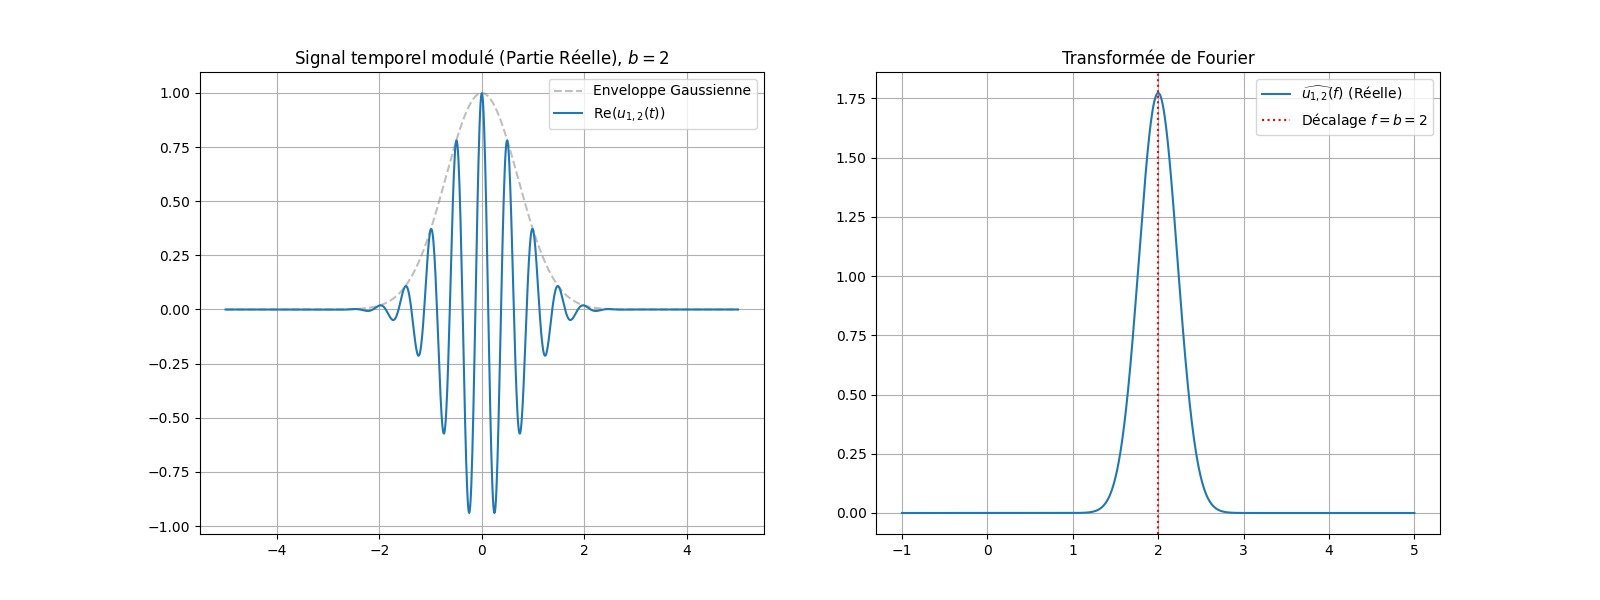

In [148]:
a_1, b_mod = 1, 2
t_15 = np.linspace(-5, 5, 1000)
f_15 = np.linspace(-1, 5, 1000)

u_1b_t = u_ab(t_15, a_1, b_mod)
TF_u_1b_f = TF_u_ab_exacte(f_15, a_1, b_mod)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(t_15, u_a(t_15, a_1), '--', color='gray', alpha=0.5, label='Enveloppe Gaussienne')
ax1.plot(t_15, np.real(u_1b_t), label=r'Re($u_{1,2}(t)$)')
ax1.set_title(r'Signal temporel modulé (Partie Réelle), $b=2$')
ax1.legend()
ax1.grid(True)

ax2.plot(f_15, TF_u_1b_f, label=r'$\widehat{u_{1,2}}(f)$ (Réelle)')
ax2.axvline(x=b_mod, color='red', linestyle=':', label=f'Décalage $f=b=2$')
ax2.set_title(r'Transformée de Fourier')
ax2.legend()
ax2.grid(True)

plt.show()

In [149]:
T = 12      
N = 1024    
a = 1        
b = 2        

k = np.arange(N)
t_k = -T/2 + k * T / N

u = u_ab(t_k, a, b)  

# Calcul de la TFD et spectre
start_time = time.time()
tfd2 = np.fft.fft(u)
spectre = T * np.abs(tfd2) / N

#### 16) Tracer sur le même graphique, l'approximation de la transformée de Fourier de $u_{1,b}$ en utilisant DFT ainsi que la transformée de Fourier exacte de $u_{1,b}$ programmée à la question 14).  Vous pourrez utiliser la commande `plt.subplots()` pour tracer plusieurs graphiques, chacun correspondant à une valeur différente de b. 

#### **1 pt** : pour graphique avec DFT + exact sur le même graphique
#### **0.5 pt** : légende présente et claire
#### **1 pt** : pour subplot (seulement 0.5 sinon, mais quand même plusieurs valeurs de b)


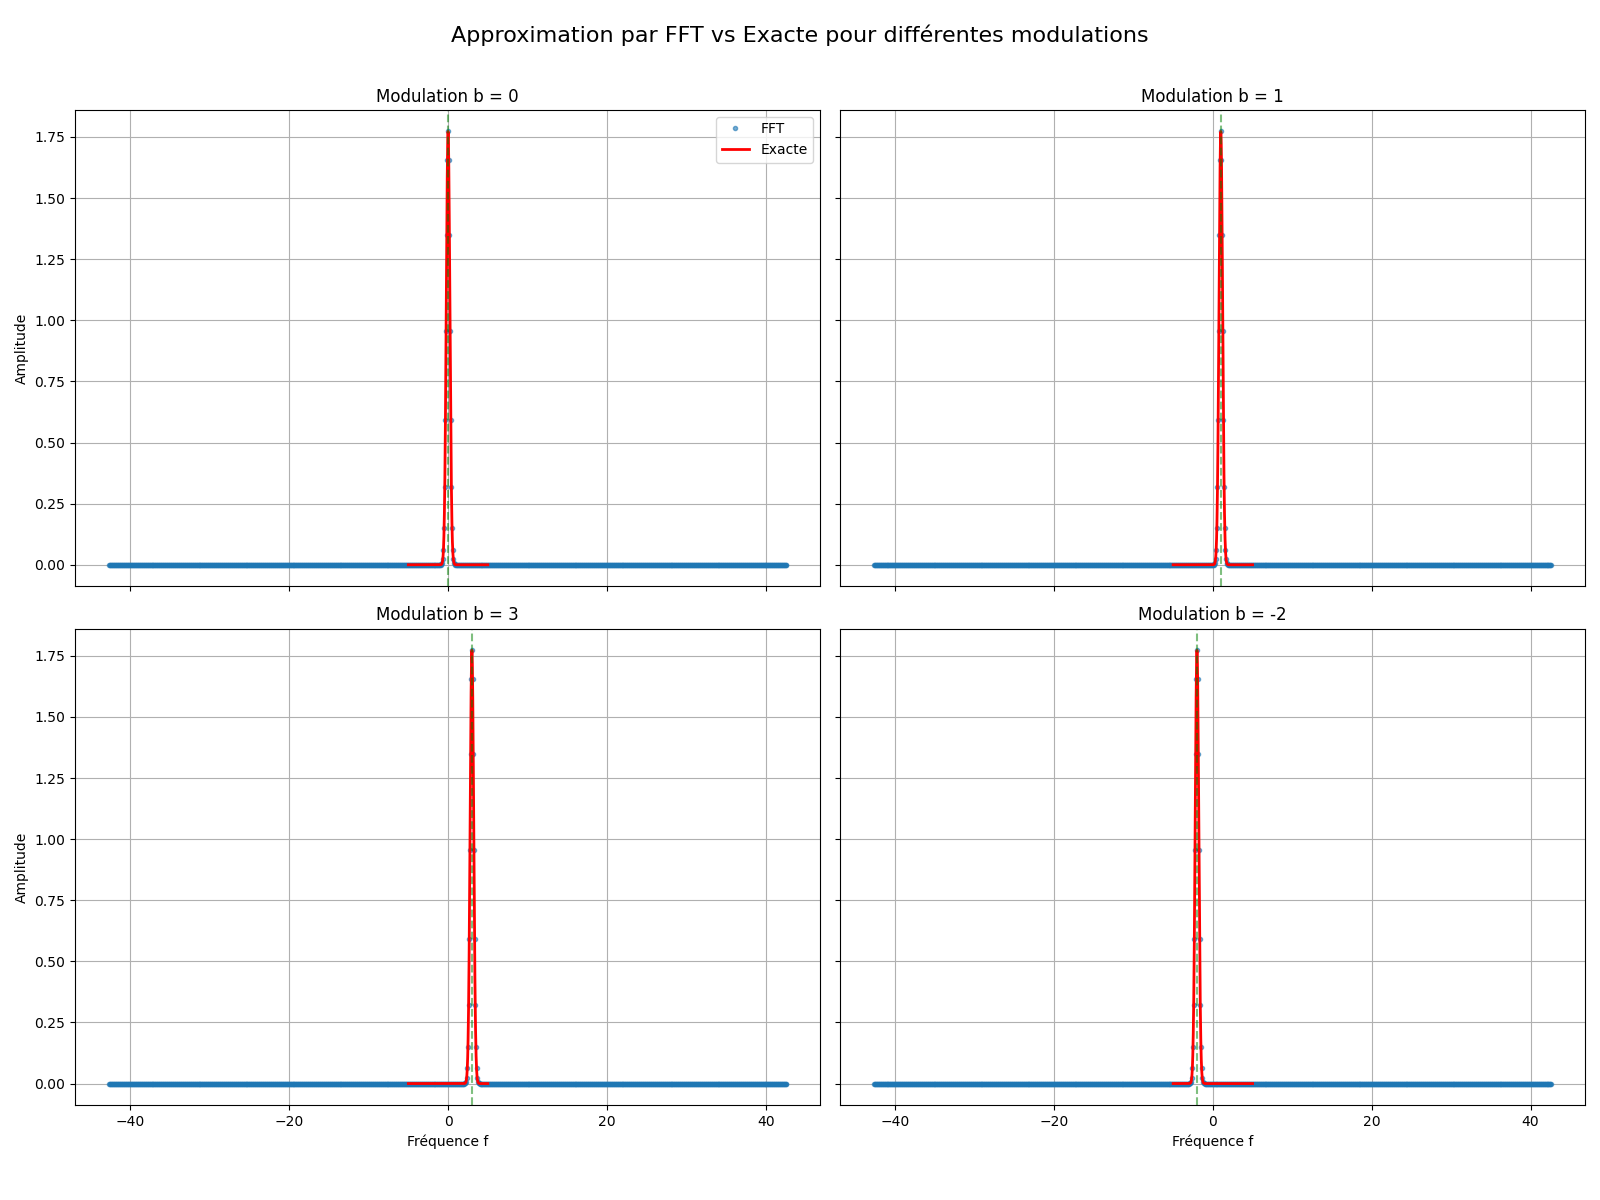

In [150]:
T_16, N_16, a_1 = 12, 1024, 1
b_values = [0, 1, 3, -2]

freqs_16 = scipy.fft.fftfreq(N_16, d=T_16/N_16)
freqs_16_shift = scipy.fft.fftshift(freqs_16)
m_indices = np.arange(N_16)

fig, axs = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle(r'Approximation par FFT vs Exacte pour différentes modulations', fontsize=16)

t_k_16 = -T_16/2 + np.arange(N_16) * T_16 / N_16
f_exact_grid = np.linspace(-5, 5, 1000)

for i, b in enumerate(b_values):
    ax = axs[i // 2, i % 2]
    u_ech = u_ab(t_k_16, a_1, b)
    
    U = scipy.fft.fft(u_ech)
    Stn = (T_16 / N_16) * np.exp(1j * np.pi * m_indices) * U
    Stn_shift = scipy.fft.fftshift(Stn)
    
    ax.plot(freqs_16_shift, np.abs(Stn_shift), 'o', markersize=3, label='FFT', alpha=0.6)
    ax.plot(f_exact_grid, TF_u_ab_exacte(f_exact_grid, a_1, b), color='red', linewidth=2, label='Exacte')
    ax.axvline(x=b, color='green', linestyle='--', alpha=0.5)
    
    ax.set_title(f'Modulation b = {b}')
    ax.grid(True)
    if i // 2 == 1: ax.set_xlabel('Fréquence f')
    if i % 2 == 0: ax.set_ylabel('Amplitude')
    if i == 0: ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## **Partie III : Utilisation de la fft pour calculer un produit de convolution** (Bonus : 4 points)

On rappelle que le produit de convolution de deux signaux $t \mapsto h(t)$ et $t \mapsto g(t)$ est définie par :

$$
h * g(t) = \int_{-\infty}^{+\infty} h(x) g(t - x) \, dx
$$

En TD machine, nous avons utilisé des méthodes d'intégration numérique pré-programmées disponibles dans le module `scipy.integrate` pour calculer 
l'intégrale. Cependant, ce calcul n'est pas optimal.

Le but de cette partie est d'utiliser l'algorithme de fft pour calculer ce produit de convolution.

On suppose que $h$ et $g$ sont deux fonctions $L^1(\mathbb{R})$ à support borné.

Dans ce cas, on a 
   $$
   h * g(t) = \mathcal{F}^{-1} \left[ \mathcal{F}(h) \cdot \mathcal{F}(g) \right](t) \,\,\,\,\,\,\,\,\,\,\,\,\,\,\,\,(\star \star)
   $$

   où $\mathcal{F}$ est la Transformée de Fourier et $\mathcal{F}^{-1}$ est la Transformée de Fourier Inverse.


#### 17) a) Implémenter un algorithme utilisant la transformée de Fourier rapide (FFT) pour calculer le produit de convolution de deux fonctions $\Pi*\Pi(t)$, avec $ \Pi$ la porte unité, en vous appuyant sur l'égalité $(\star \star)$.
#### b) Représenter graphiquement le résultat obtenu et comparer-le avec le résultat exact du produit de convolution $\Pi * \Pi (t)$ (voir cours/TD) en les traçant sur le même graphique.  


#### **1,5 pts** :  pour 17 (a)
#### **0,5 pt** :  pour 17 (b) pour graphique légendé

L'égalité utilisée est :
$$h * g(t) = \mathcal{F}^{-1} \left[ \mathcal{F}(h) \cdot \mathcal{F}(g) \right](t)$$
Le produit de convolution de deux portes unités (de support $[-0.5, 0.5]$) est la fonction triangle (de support $[-1, 1]$).

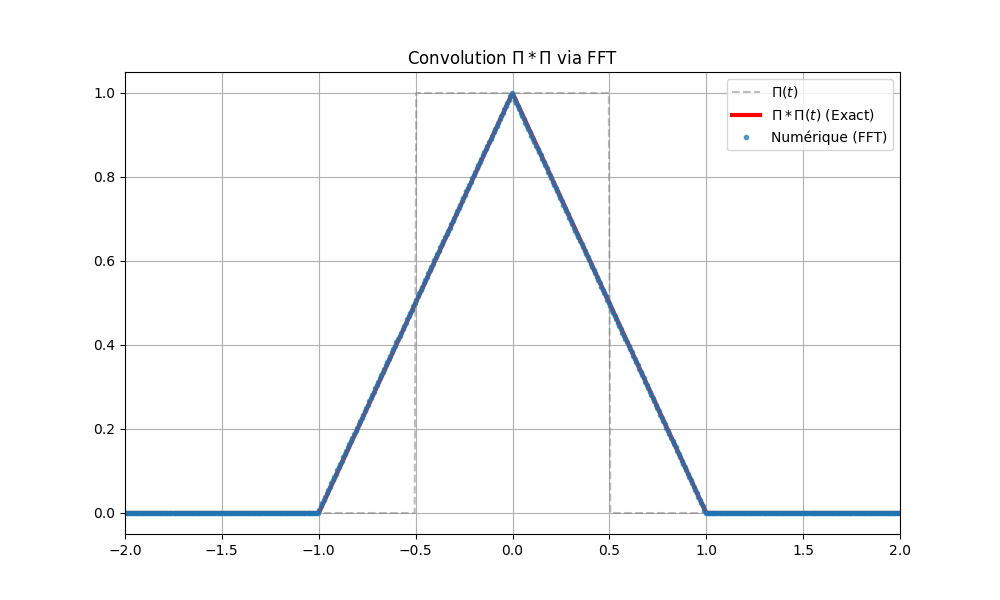

In [151]:
def convolution_fft(t_ech, h_ech, g_ech, T_window):
    N = len(h_ech)
    dt = T_window / N
    
    # 1. TFD (FFT brute)
    H_m = scipy.fft.fft(h_ech)
    G_m = scipy.fft.fft(g_ech)
    
    # 2. Produit spectral
    Conv_TFD = H_m * G_m
    
    # 3. IFFT et normalisation par dt (pour retrouver l'amplitude de l'intégrale temporelle)
    conv_ech = scipy.fft.ifft(Conv_TFD) * dt
    
    # Recalage du zero-frequency component
    return t_ech, scipy.fft.fftshift(np.real(conv_ech))

# Application à la porte
T_porte, N_porte = 4, 512
t_porte = np.linspace(-T_porte/2, T_porte/2, N_porte)
pi_t = np.where(np.abs(t_porte) <= 0.5, 1.0, 0.0)

# Exact
conv_exact_t = np.where(np.abs(t_porte) <= 1.0, 1.0 - np.abs(t_porte), 0.0)

# Numérique
_, conv_pi_pi_num = convolution_fft(t_porte, pi_t, pi_t, T_porte)

# Tracé
plt.figure(figsize=(10, 6))
plt.plot(t_porte, pi_t, '--', color='gray', alpha=0.5, label=r'$\Pi(t)$')
plt.plot(t_porte, conv_exact_t, color='red', linewidth=3, label=r'$\Pi*\Pi(t)$ (Exact)')
plt.plot(t_porte, conv_pi_pi_num, 'o', markersize=3, label='Numérique (FFT)', alpha=0.7)
plt.title(r'Convolution $\Pi*\Pi$ via FFT')
plt.xlim(-2, 2)
plt.legend()
plt.grid(True)
plt.show()

#### 18) a) Montrer que $\displaystyle u_{\pi}*u_{\pi}(t)=  \frac{e^{-\pi t^2/2}}{\sqrt{2}}$
#### b) Tracer sur le même graphique le produit de convolution exact $u_{\pi} * u_{\pi}$ obtenu à la question a), ainsi que le résultat numérique obtenu en utilisant l'algorithme basé sur la transformée de Fourier rapide (FFT).

#### **1 pt** :  pour 18 (a)
#### **1 pt** :  pour 18 (b) pour graphique légendé

**Démonstration :**

On passe dans le domaine fréquentiel : $\mathcal{F}(u_{\pi}*u_{\pi})(f) = \widehat{u_\pi}(f) \cdot \widehat{u_\pi}(f)$.
On sait que $\widehat{u_\pi}(f) = e^{-\pi f^2}$.
Donc :
$$\mathcal{F}(u_{\pi}*u_{\pi})(f) = e^{-\pi f^2} \cdot e^{-\pi f^2} = e^{-2\pi f^2}$$

Appliquons la TF inverse :
$$u_{\pi}*u_{\pi}(t) = \mathcal{F}^{-1}(e^{-2\pi f^2})(t)$$

On connait la forme générale : $\mathcal{F}(A e^{-\alpha t^2})(f) = A \sqrt{\frac{\pi}{\alpha}} e^{-\frac{\pi^2 f^2}{\alpha}}$.
Par identification avec $e^{-2\pi f^2}$, on pose :
$$\frac{\pi^2}{\alpha} = 2\pi \implies \alpha = \frac{\pi}{2}$$
$$A \sqrt{\frac{\pi}{\alpha}} = 1 \implies A \sqrt{\frac{\pi}{\pi/2}} = 1 \implies A\sqrt{2} = 1 \implies A = \frac{1}{\sqrt{2}}$$

Ainsi, le signal temporel correspondant est :
$$u_{\pi}*u_{\pi}(t) = \frac{1}{\sqrt{2}} e^{-\frac{\pi}{2} t^2}$$

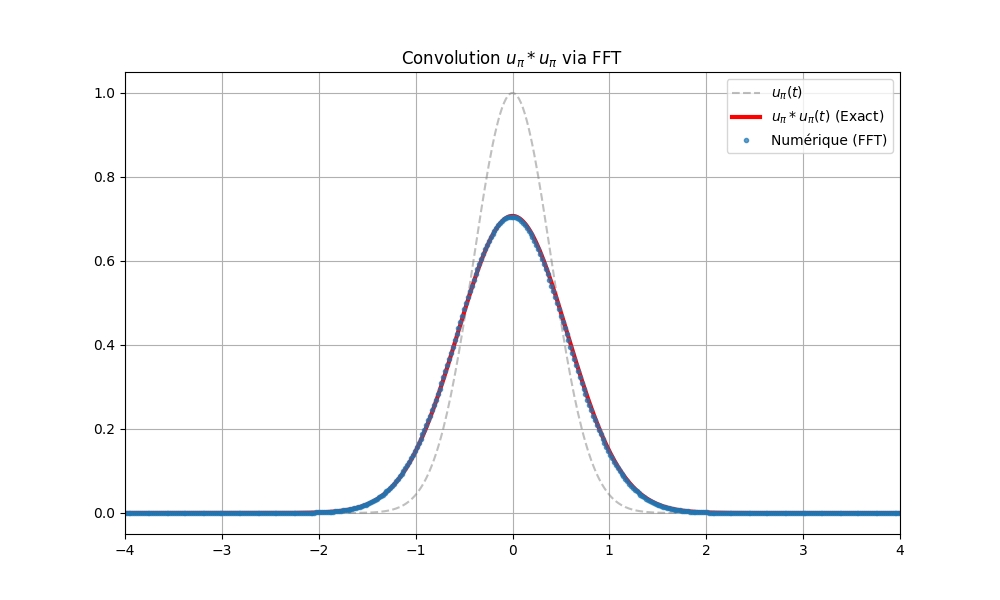

In [152]:
T_gauss, N_gauss = 10, 512
t_g = np.linspace(-T_gauss/2, T_gauss/2, N_gauss)

u_pi_ech = u_a(t_g, np.pi)

# Numérique
_, conv_g_num = convolution_fft(t_g, u_pi_ech, u_pi_ech, T_gauss)

# Exacte
conv_g_exact = np.exp(-np.pi * t_g**2 / 2) / np.sqrt(2)

plt.figure(figsize=(10, 6))
plt.plot(t_g, u_pi_ech, '--', color='gray', alpha=0.5, label=r'$u_\pi(t)$')
plt.plot(t_g, conv_g_exact, color='red', linewidth=3, label=r'$u_\pi*u_\pi(t)$ (Exact)')
plt.plot(t_g, conv_g_num, 'o', markersize=3, label='Numérique (FFT)', alpha=0.7)
plt.title(r'Convolution $u_\pi*u_\pi$ via FFT')
plt.xlim(-4, 4)
plt.legend()
plt.grid(True)
plt.show()